In [2]:
!pip install ucimlrepo -q

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

In [4]:
 # Step 1: Fetch the raw dataset from UCI
# ---------------------------------------------------------
statlog_german_credit_data = fetch_ucirepo(id=144)

X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

df = pd.concat([X, y], axis=1)


In [5]:

# Step 2: Rename columns to meaningful names
# ---------------------------------------------------------
column_names = [
    "checking_account_status", "duration_months", "credit_history",
    "purpose", "credit_amount", "savings_account", "employment_since",
    "installment_rate_pct", "personal_status_sex", "other_debtors",
    "present_residence_since", "property", "age", "other_installment_plans",
    "housing", "existing_credits_count", "job", "dependents_count",
    "telephone", "foreign_worker", "credit_risk"
]
df.columns = column_names

In [6]:
# Step 3: Decode the cryptic A11/A34/... codes into labels
# ---------------------------------------------------------
checking_account_map = {
    "A11": "< 0 DM", "A12": "0 to 200 DM",
    "A13": ">= 200 DM", "A14": "no checking account"
}
credit_history_map = {
    "A30": "no credits / all paid duly elsewhere",
    "A31": "all credits at this bank paid duly",
    "A32": "existing credits paid duly till now",
    "A33": "delay in paying off in the past",
    "A34": "critical account / other credits existing"
}
purpose_map = {
    "A40": "new car", "A41": "used car", "A42": "furniture/equipment",
    "A43": "radio/television", "A44": "domestic appliances",
    "A45": "repairs", "A46": "education", "A47": "vacation",
    "A48": "retraining", "A49": "business", "A410": "other"
}
savings_map = {
    "A61": "< 100 DM", "A62": "100 to 500 DM", "A63": "500 to 1000 DM",
    "A64": ">= 1000 DM", "A65": "unknown / no savings account"
}
employment_map = {
    "A71": "unemployed", "A72": "< 1 year", "A73": "1 to 4 years",
    "A74": "4 to 7 years", "A75": ">= 7 years"
}
personal_status_map = {
    "A91": "male: divorced/separated", "A92": "female: divorced/separated/married",
    "A93": "male: single", "A94": "male: married/widowed", "A95": "female: single"
}
other_debtors_map = {
    "A101": "none", "A102": "co-applicant", "A103": "guarantor"
}
property_map = {
    "A121": "real estate", "A122": "building society savings/life insurance",
    "A123": "car or other property", "A124": "unknown / no property"
}
other_installment_map = {
    "A141": "bank", "A142": "stores", "A143": "none"
}
housing_map = {
    "A151": "rent", "A152": "own", "A153": "for free"
}
job_map = {
    "A171": "unemployed/unskilled non-resident",
    "A172": "unskilled resident",
    "A173": "skilled employee/official",
    "A174": "management/self-employed/highly qualified"
}
telephone_map = {
    "A191": "none", "A192": "registered"
}
foreign_worker_map = {
    "A201": "yes", "A202": "no"
}
credit_risk_map = {1: "good", 2: "bad"}

df["checking_account_status"] = df["checking_account_status"].map(checking_account_map)
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["purpose"] = df["purpose"].map(purpose_map)
df["savings_account"] = df["savings_account"].map(savings_map)
df["employment_since"] = df["employment_since"].map(employment_map)
df["personal_status_sex"] = df["personal_status_sex"].map(personal_status_map)
df["other_debtors"] = df["other_debtors"].map(other_debtors_map)
df["property"] = df["property"].map(property_map)
df["other_installment_plans"] = df["other_installment_plans"].map(other_installment_map)
df["housing"] = df["housing"].map(housing_map)
df["job"] = df["job"].map(job_map)
df["telephone"] = df["telephone"].map(telephone_map)
df["foreign_worker"] = df["foreign_worker"].map(foreign_worker_map)
df["credit_risk"] = df["credit_risk"].map(credit_risk_map)


Create your project folder in Drive

In [7]:
import os
project_path = '/content/drive/MyDrive/credit-risk-germany'
os.makedirs(f'{project_path}/data/raw', exist_ok=True)
os.makedirs(f'{project_path}/data/processed', exist_ok=True)
os.makedirs(f'{project_path}/notebooks', exist_ok=True)
os.makedirs(f'{project_path}/reports', exist_ok=True)
print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/credit-risk-germany


Save loaded csv file


In [10]:
df.to_csv(f'{project_path}/data/raw/german_credit_clean.csv', index=False)
print("Saved to:", f'{project_path}/data/raw/german_credit_clean.csv')

Saved to: /content/drive/MyDrive/credit-risk-germany/data/raw/german_credit_clean.csv


In [11]:
check = pd.read_csv(f'{project_path}/data/raw/german_credit_clean.csv')

SQL

Load your clean CSV and create a SQLite database

In [12]:
import sqlite3
import pandas as pd

# Load the clean data from Phase 1
df = pd.read_csv(f'{project_path}/data/raw/german_credit_clean.csv')

# Create (or connect to) a SQLite database file in your project
db_path = f'{project_path}/data/processed/credit_risk.db'
conn = sqlite3.connect(db_path)

# Write the dataframe into a SQL table
df.to_sql('loans_raw', conn, if_exists='replace', index=False)

print("Database created at:", db_path)
print("Rows loaded:", pd.read_sql('SELECT COUNT(*) FROM loans_raw', conn))

Database created at: /content/drive/MyDrive/credit-risk-germany/data/processed/credit_risk.db
Rows loaded:    COUNT(*)
0      1000


In [13]:
# Default rate by purpose of loan
query1 = """
SELECT purpose,
       COUNT(*) as total_loans,
       SUM(CASE WHEN credit_risk = 'bad' THEN 1 ELSE 0 END) as bad_loans,
       ROUND(100.0 * SUM(CASE WHEN credit_risk = 'bad' THEN 1 ELSE 0 END) / COUNT(*), 1) as default_rate_pct
FROM loans_raw
GROUP BY purpose
ORDER BY default_rate_pct DESC
"""
pd.read_sql(query1, conn)

,purpose,total_loans,bad_loans,default_rate_pct
0,education,50,22,44.0
1,other,12,5,41.7
2,new car,234,89,38.0
3,repairs,22,8,36.4
4,business,97,34,35.1
5,domestic appliances,12,4,33.3
6,furniture/equipment,181,58,32.0
7,radio/television,280,62,22.1
8,used car,103,17,16.5
9,retraining,9,1,11.1


In [14]:
# Default rate by checking account status
query2 = """
SELECT checking_account_status,
       COUNT(*) as total_loans,
       ROUND(100.0 * SUM(CASE WHEN credit_risk = 'bad' THEN 1 ELSE 0 END) / COUNT(*), 1) as default_rate_pct
FROM loans_raw
GROUP BY checking_account_status
ORDER BY default_rate_pct DESC
"""
pd.read_sql(query2, conn)

,checking_account_status,total_loans,default_rate_pct
0,< 0 DM,274,49.3
1,0 to 200 DM,269,39.0
2,>= 200 DM,63,22.2
3,no checking account,394,11.7


In [15]:
# Average credit amount and age by risk category
query3 = """
SELECT credit_risk,
       ROUND(AVG(credit_amount), 0) as avg_credit_amount,
       ROUND(AVG(age), 1) as avg_age,
       COUNT(*) as count
FROM loans_raw
GROUP BY credit_risk
"""
pd.read_sql(query3, conn)

,credit_risk,avg_credit_amount,avg_age,count
0,bad,3938.0,34.0,300
1,good,2985.0,36.2,700


Build a cleaning & transformation layer

In [16]:
def clean_and_transform(df):
    """
    Cleans and engineers features for the credit risk pipeline.
    """
    df = df.copy()

    # Check for missing values
    missing = df.isna().sum()
    if missing.sum() > 0:
        print("Warning: missing values found:\n", missing[missing > 0])

    # Feature engineering
    df['credit_per_month'] = df['credit_amount'] / df['duration_months']
    df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 50, 100],
                              labels=['18-25', '26-35', '36-50', '50+'])
    df['is_long_term_loan'] = (df['duration_months'] > 24).astype(int)

    # Encode target as binary for modelling later (1 = bad/default, 0 = good)
    df['default_flag'] = (df['credit_risk'] == 'bad').astype(int)

    return df

df_processed = clean_and_transform(df)
df_processed.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,existing_credits_count,job,dependents_count,telephone,foreign_worker,credit_risk,credit_per_month,age_group,is_long_term_loan,default_flag
0,< 0 DM,6,critical account / other credits existing,radio/television,1169,unknown / no savings account,>= 7 years,4,male: single,none,...,2,skilled employee/official,1,registered,yes,good,194.833333,50+,0,0
1,0 to 200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1 to 4 years,2,female: divorced/separated/married,none,...,1,skilled employee/official,1,none,yes,bad,123.979167,18-25,1,1
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4 to 7 years,2,male: single,none,...,1,unskilled resident,2,none,yes,good,174.666667,36-50,0,0
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4 to 7 years,2,male: single,guarantor,...,1,skilled employee/official,2,none,yes,good,187.666667,36-50,1,0
4,< 0 DM,24,delay in paying off in the past,new car,4870,< 100 DM,1 to 4 years,3,male: single,none,...,2,skilled employee/official,2,none,yes,bad,202.916667,50+,0,1


Save the processed table back to SQL and CSV

In [17]:
# Save engineered features into a new table
df_processed.to_sql('loans_processed', conn, if_exists='replace', index=False)

# Also save as CSV for easy access in later notebooks
df_processed.to_csv(f'{project_path}/data/processed/loans_processed.csv', index=False)

print("Processed data saved — SQL table 'loans_processed' and CSV both updated.")

Processed data saved — SQL table 'loans_processed' and CSV both updated.


EDA


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Style settings — makes charts look professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Load processed data from SQLite
project_path = '/content/drive/MyDrive/credit-risk-germany'
db_path = f'{project_path}/data/processed/credit_risk.db'
conn = sqlite3.connect(db_path)
df = pd.read_sql('SELECT * FROM loans_processed', conn)

print("Shape:", df.shape)
df.head()

Shape: (1000, 25)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,existing_credits_count,job,dependents_count,telephone,foreign_worker,credit_risk,credit_per_month,age_group,is_long_term_loan,default_flag
0,< 0 DM,6,critical account / other credits existing,radio/television,1169,unknown / no savings account,>= 7 years,4,male: single,none,...,2,skilled employee/official,1,registered,yes,good,194.833333,50+,0,0
1,0 to 200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1 to 4 years,2,female: divorced/separated/married,none,...,1,skilled employee/official,1,none,yes,bad,123.979167,18-25,1,1
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4 to 7 years,2,male: single,none,...,1,unskilled resident,2,none,yes,good,174.666667,36-50,0,0
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4 to 7 years,2,male: single,guarantor,...,1,skilled employee/official,2,none,yes,good,187.666667,36-50,1,0
4,< 0 DM,24,delay in paying off in the past,new car,4870,< 100 DM,1 to 4 years,3,male: single,none,...,2,skilled employee/official,2,none,yes,bad,202.916667,50+,0,1


Target dbn


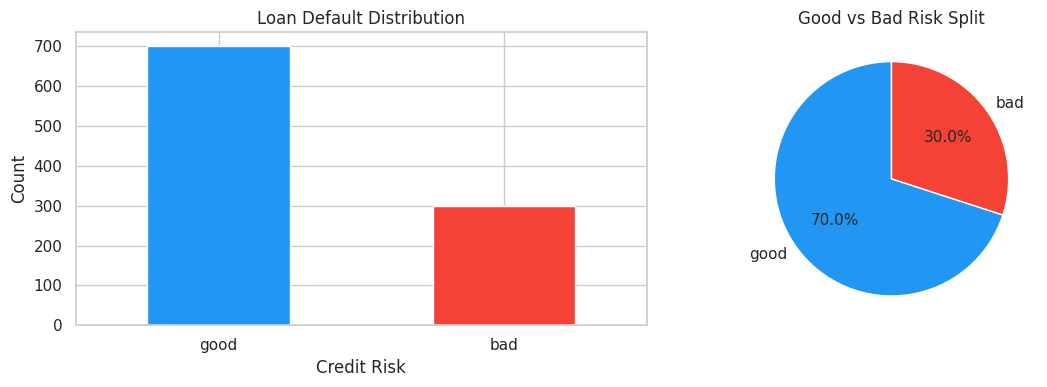

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['credit_risk'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Default Distribution')
axes[0].set_xlabel('Credit Risk')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Percentage pie chart
df['credit_risk'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#2196F3','#F44336'],
    startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Good vs Bad Risk Split')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{project_path}/reports/01_target_distribution.png', dpi=150)
plt.show()

Numeric features dbn

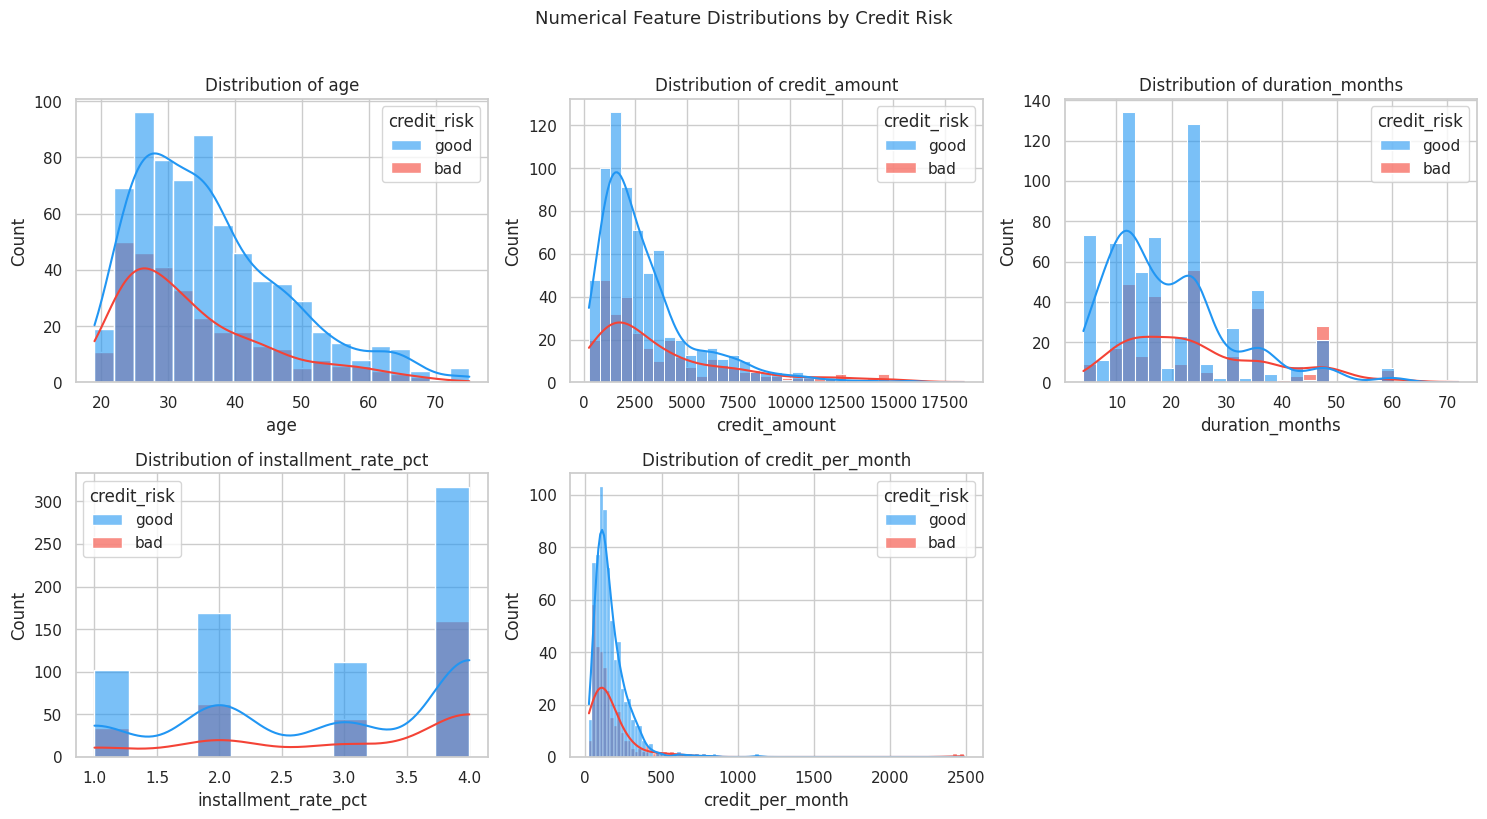

In [20]:
numerical_cols = ['age', 'credit_amount', 'duration_months',
                  'installment_rate_pct', 'credit_per_month']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='credit_risk',
                 kde=True, ax=axes[i],
                 palette={'good':'#2196F3', 'bad':'#F44336'},
                 alpha=0.6)
    axes[i].set_title(f'Distribution of {col}')

axes[5].set_visible(False)  # hide the empty 6th panel
plt.suptitle('Numerical Feature Distributions by Credit Risk', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{project_path}/reports/02_numerical_distributions.png', dpi=150)
plt.show()

Default rate key categorical features

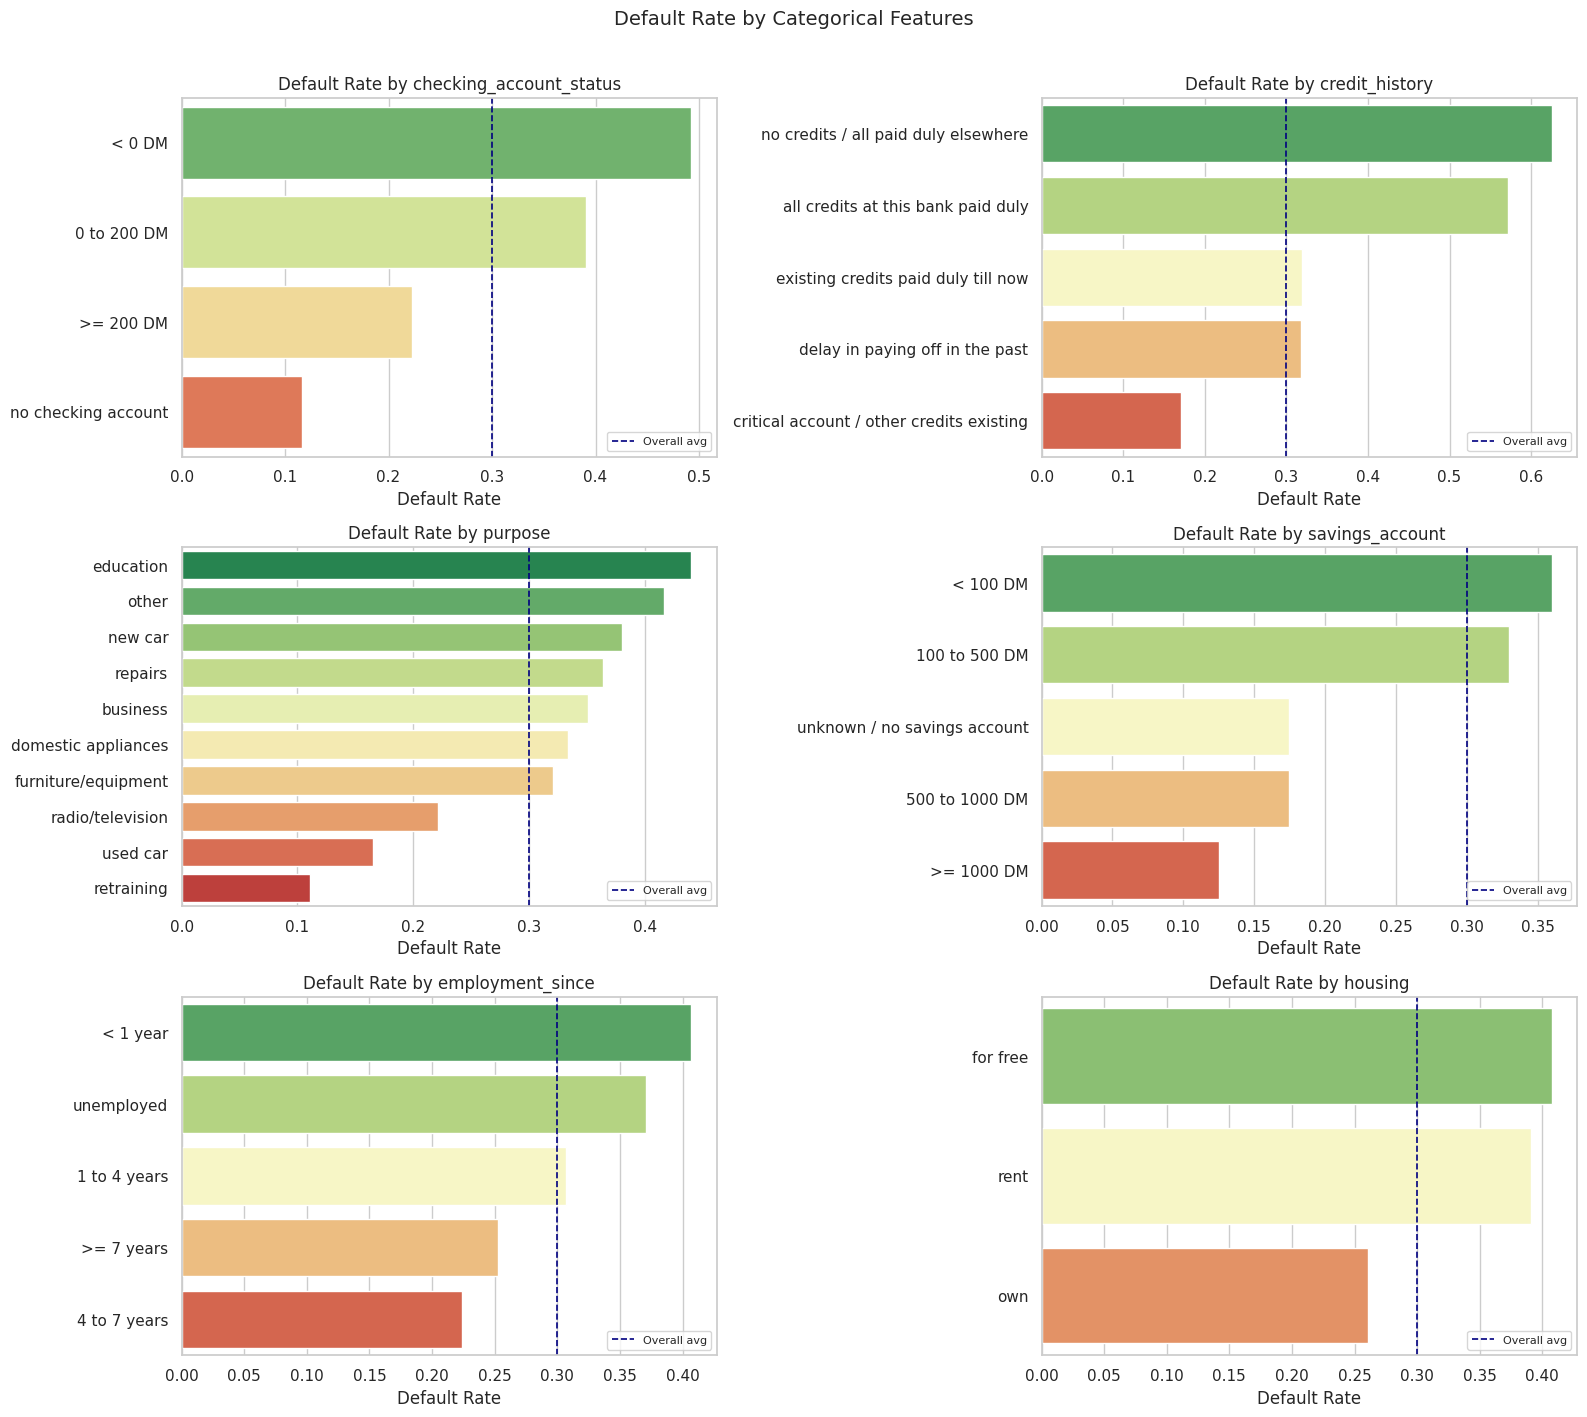

In [21]:
cat_cols = ['checking_account_status', 'credit_history',
            'purpose', 'savings_account', 'employment_since', 'housing']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = (df.groupby(col)['default_flag']
                      .mean()
                      .sort_values(ascending=False)
                      .reset_index())
    default_rate.columns = [col, 'default_rate']

    sns.barplot(data=default_rate, x='default_rate', y=col,
                ax=axes[i], palette='RdYlGn_r')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate')
    axes[i].set_ylabel('')
    axes[i].axvline(df['default_flag'].mean(), color='navy',
                    linestyle='--', linewidth=1.2, label='Overall avg')
    axes[i].legend(fontsize=8)

plt.suptitle('Default Rate by Categorical Features', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(f'{project_path}/reports/03_default_by_category.png', dpi=150)
plt.show()

Correlation heatmap

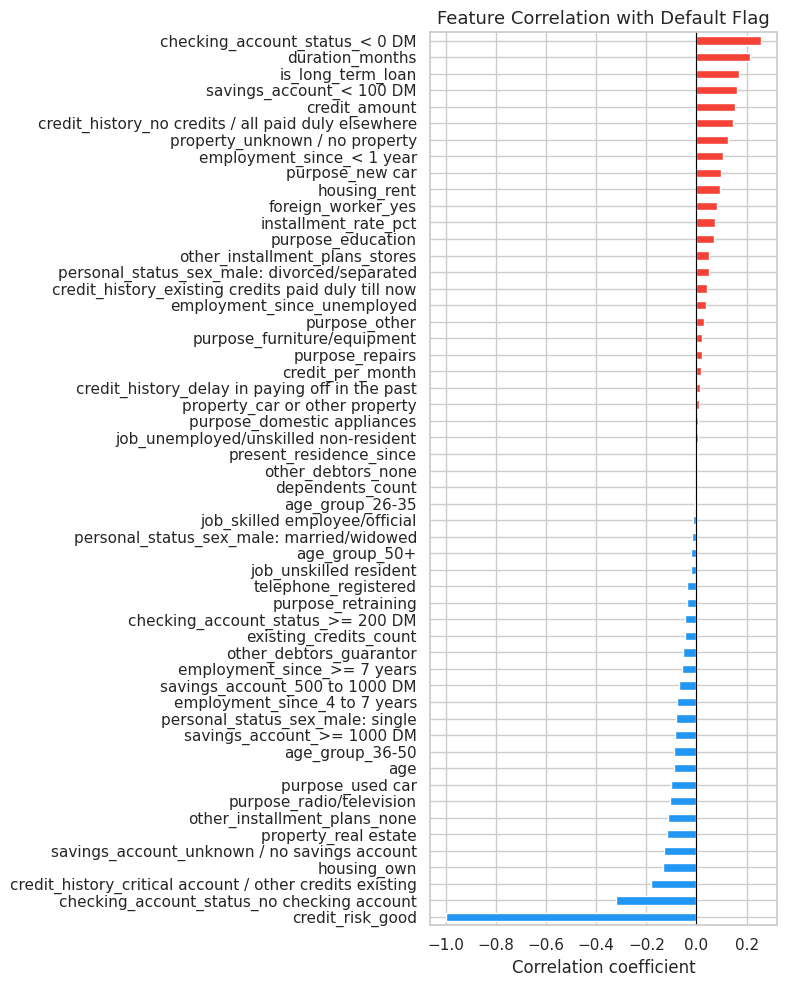

In [22]:
# Encode categorical columns as numbers just for correlation purposes
df_encoded = pd.get_dummies(df.select_dtypes(include=['object', 'category']),
                             drop_first=True)
df_numeric = pd.concat([df.select_dtypes(include='number'), df_encoded], axis=1)

# Correlations with the target
corr_with_target = (df_numeric.corr()['default_flag']
                               .drop('default_flag')
                               .sort_values())

plt.figure(figsize=(8, 10))
corr_with_target.plot(kind='barh',
    color=['#F44336' if x > 0 else '#2196F3' for x in corr_with_target])
plt.title('Feature Correlation with Default Flag', fontsize=13)
plt.xlabel('Correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{project_path}/reports/04_correlation_target.png', dpi=150)
plt.show()

Age vs credit amount scatter

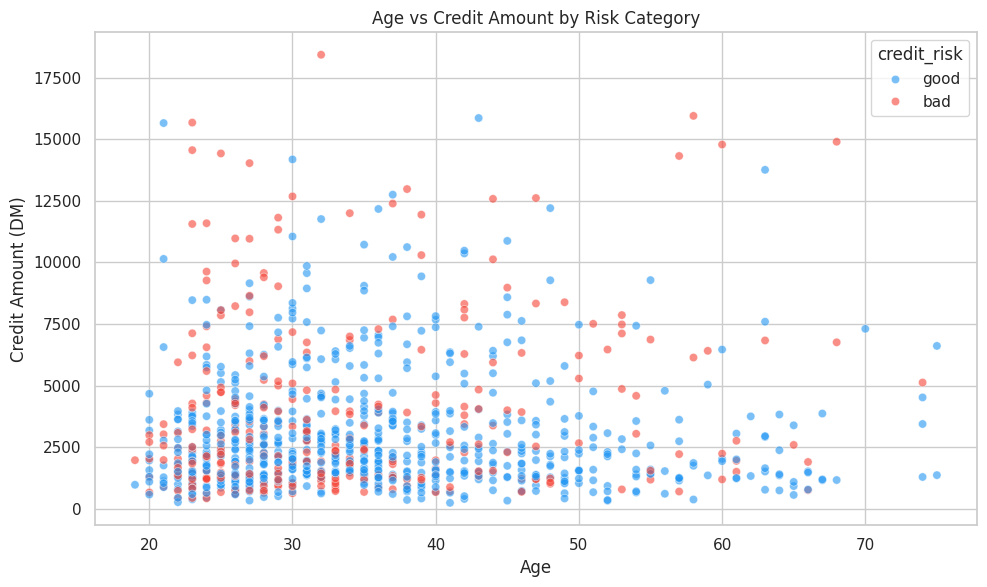

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='credit_amount',
                hue='credit_risk', alpha=0.6,
                palette={'good':'#2196F3', 'bad':'#F44336'})
plt.title('Age vs Credit Amount by Risk Category')
plt.xlabel('Age')
plt.ylabel('Credit Amount (DM)')
plt.tight_layout()
plt.savefig(f'{project_path}/reports/05_age_vs_credit_scatter.png', dpi=150)
plt.show()

additional features

In [24]:
# Load back the full processed dataframe
df = pd.read_sql('SELECT * FROM loans_processed', conn)

# 1. Debt-to-duration ratio — higher = more pressure per month
df['debt_burden'] = df['credit_amount'] * df['installment_rate_pct'] / 100

# 2. Employment stability score
employment_order = {
    'unemployed': 0, '< 1 year': 1, '1 to 4 years': 2,
    '4 to 7 years': 3, '>= 7 years': 4
}
df['employment_score'] = df['employment_since'].map(employment_order)

# 3. Savings strength score
savings_order = {
    'unknown / no savings account': 0,
    '< 100 DM': 1, '100 to 500 DM': 2,
    '500 to 1000 DM': 3, '>= 1000 DM': 4
}
df['savings_score'] = df['savings_account'].map(savings_order)

# 4. High risk flag — no checking account + no savings
df['high_risk_profile'] = (
    (df['checking_account_status'] == 'no checking account') &
    (df['savings_account'] == 'unknown / no savings account')
).astype(int)

# Save updated features back to SQL and CSV
df.to_sql('loans_features', conn, if_exists='replace', index=False)
df.to_csv(f'{project_path}/data/processed/loans_features.csv', index=False)

print("Feature engineering done. New columns added:")
print(['debt_burden', 'employment_score', 'savings_score', 'high_risk_profile'])

Feature engineering done. New columns added:
['debt_burden', 'employment_score', 'savings_score', 'high_risk_profile']
